# Expanded_data_with_more_features dataset

Data Dictionary (column description)
- Gender: Gender of the student (male/female)
- EthnicGroup: Ethnic group of the student (group A to E)
- ParentEduc: Parent(s) education background (from some_highschool to master's degree)
- LunchType: School lunch type (standard or free/reduced)
- TestPrep: Test preparation course followed (completed or none)
- ParentMaritalStatus: Parent(s) marital status (married/single/widowed/divorced)
- PracticeSport: How often the student parctice sport (never/sometimes/regularly))
- IsFirstChild: If the child is first child in the family or not (yes/no)
- NrSiblings: Number of siblings the student has (0 to 7)
- TransportMeans: Means of transport to school (schoolbus/private)
- WklyStudyHours: Weekly self-study hours(less that 5hrs; between 5 and 10hrs; more than 10hrs)
- MathScore: math test score(0-100)
- ReadingScore: reading test score(0-100)
- WritingScore: writing test score(0-100)

# house_data dataset

- id: Unique identifier for each property.
- date: Date when the property was sold.
- price: Sale price of the property.
- bedrooms: Number of bedrooms in the house.
- bathrooms: Number of bathrooms in the house.
- sqft_living: Square footage of the living area.
- sqft_lot: Square footage of the lot.
- floors: Number of floors in the house.
- waterfront: Indicates if the property has a waterfront view (binary: 0 = no, 1 = yes).
- view: Quality of the view from the property (numerical scale).
- condition: Condition of the house (numerical scale).
- grade: Overall grade based on building and design (numerical scale).
- sqft_above: Square footage of the house (excluding the basement).
- sqft_basement: Square footage of the basement.
- yr_built: Year the house was built.
- yr_renovated: Year the house was renovated (0 indicates no renovations).
- zipcode: ZIP code of the property.
- lat: Latitude coordinate of the property.
- long: Longitude coordinate of the property.
- sqft_living15: Average square footage of living area for the 15 nearest neighbors.
- sqft_lot15: Average square footage of lot size for the 15 nearest neighbors

# Regression Assignment Solution

This notebook solves two separate regression problems:

1. **House Data** -> predict the sale `price` from property features.
2. **Expanded Student Data** -> predict the student's `MathScore` from personal and academic features.

Each part includes: data loading, exploratory data analysis (EDA), preprocessing, training multiple regression models, and comparing results.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

---
# Part 1: House Data Dataset

## 1.1 Load and inspect the data

In [2]:
house = pd.read_csv("house_data.csv")
house.shape

(21613, 21)

In [3]:
house.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
house.isna().sum().sum()

np.int64(0)

In [6]:
house.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


There are no missing values in this dataset. The `id` column carries no predictive value and will be dropped, and `date` will be converted into numeric features instead of being used as raw text.

## 1.2 Feature engineering

In [7]:
house["date"] = pd.to_datetime(house["date"], format="%Y%m%dT%H%M%S")
house["sale_year"] = house["date"].dt.year
house["sale_month"] = house["date"].dt.month
house["house_age"] = house["sale_year"] - house["yr_built"]
house["was_renovated"] = (house["yr_renovated"] > 0).astype(int)

house = house.drop(columns=["id", "date"])
house.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,was_renovated
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,59,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,63,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,82,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,49,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,28,0


## 1.3 Exploring relationships between variables

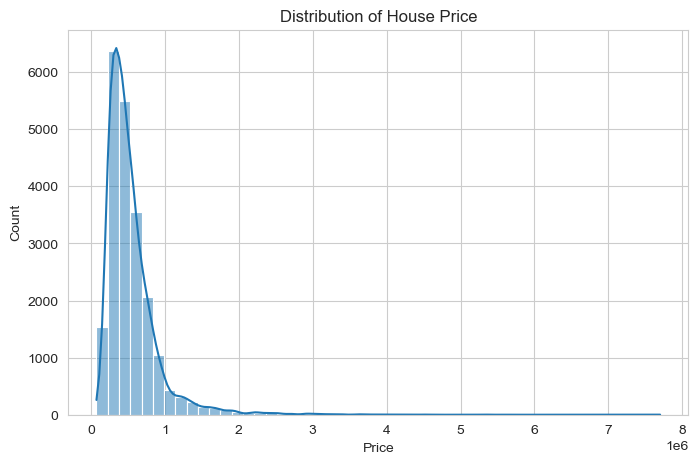

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(house["price"], bins=50, kde=True)
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.show()

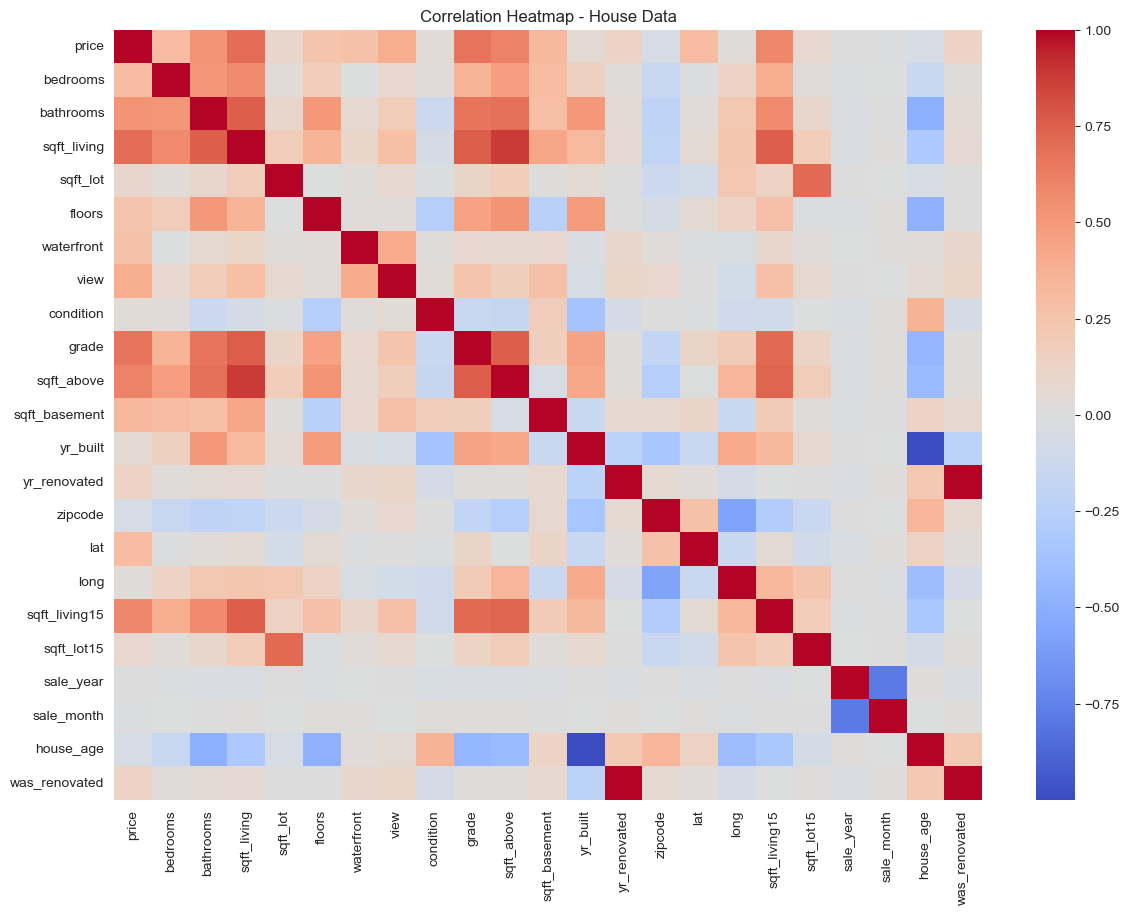

In [9]:
plt.figure(figsize=(14, 10))
corr = house.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap - House Data")
plt.show()

In [10]:
corr["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
was_renovated    0.126092
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
sale_year        0.003576
sale_month      -0.010081
zipcode         -0.053203
house_age       -0.053951
Name: price, dtype: float64

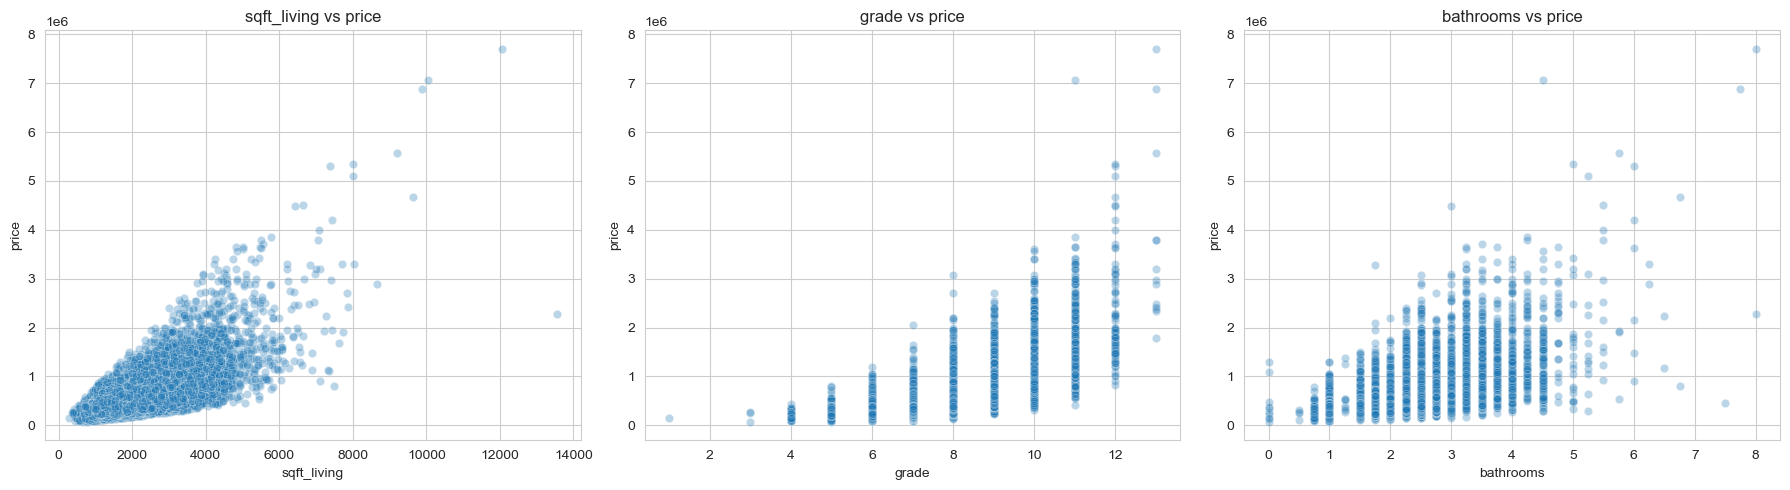

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=house, x="sqft_living", y="price", alpha=0.3, ax=axes[0])
axes[0].set_title("sqft_living vs price")
sns.scatterplot(data=house, x="grade", y="price", alpha=0.3, ax=axes[1])
axes[1].set_title("grade vs price")
sns.scatterplot(data=house, x="bathrooms", y="price", alpha=0.3, ax=axes[2])
axes[2].set_title("bathrooms vs price")
plt.tight_layout()
plt.show()

## 1.4 Preparing the data for training

In [12]:
X_house = house.drop(columns=["price"])
y_house = house["price"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

X_train_h.shape, X_test_h.shape

((17290, 22), (4323, 22))

In [34]:
numeric_features_h = X_house.columns.tolist()

preprocessor_h = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features_h)
])

## 1.5 Training the models

In [14]:
models_h = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

results_h = {}

for name, model in models_h.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_h),
        ("regressor", model)
    ])
    pipe.fit(X_train_h, y_train_h)
    preds = pipe.predict(X_test_h)

    r2 = r2_score(y_test_h, preds)
    rmse = np.sqrt(mean_squared_error(y_test_h, preds))
    mae = mean_absolute_error(y_test_h, preds)

    results_h[name] = {"R2": r2, "RMSE": rmse, "MAE": mae, "pipeline": pipe, "preds": preds}

    print(f"{name}: R2={r2:.4f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}")

Linear Regression: R2=0.7041  RMSE=211,492.53  MAE=126,642.29
Ridge Regression: R2=0.7033  RMSE=211,788.07  MAE=126,798.39
Random Forest Regressor: R2=0.8592  RMSE=145,890.56  MAE=72,524.54


## 1.6 Comparing the models

In [15]:
results_df_h = pd.DataFrame({
    name: {"R2": v["R2"], "RMSE": v["RMSE"], "MAE": v["MAE"]}
    for name, v in results_h.items()
}).T

results_df_h

,R2,RMSE,MAE
Linear Regression,0.704127,211492.529155,126642.294039
Ridge Regression,0.703300,211788.065648,126798.387609
Random Forest Regressor,0.859211,145890.556163,72524.536298


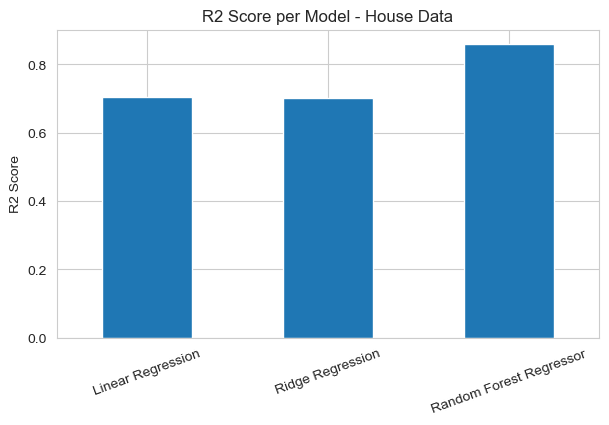

In [16]:
results_df_h["R2"].plot(kind="bar", figsize=(7, 4), title="R2 Score per Model - House Data")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

Random Forest Regressor achieves the highest R2. The plot below compares actual vs predicted prices for this model.

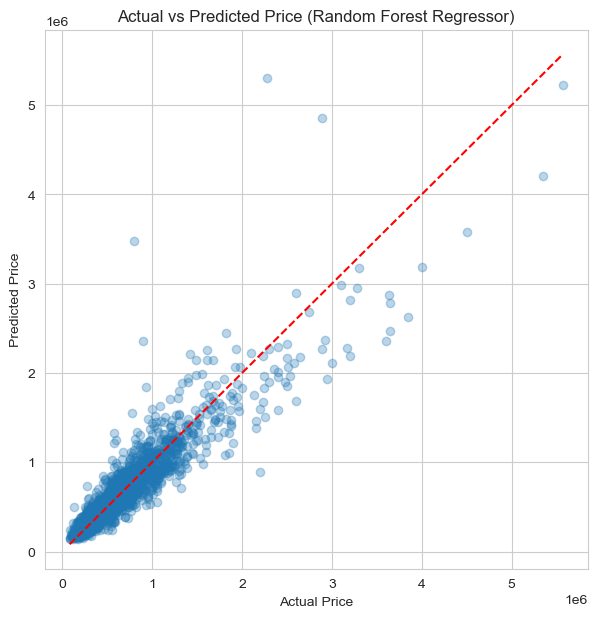

In [17]:
best_name_h = results_df_h["R2"].idxmax()
best_preds_h = results_h[best_name_h]["preds"]

plt.figure(figsize=(7, 7))
plt.scatter(y_test_h, best_preds_h, alpha=0.3)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price ({best_name_h})")
plt.show()

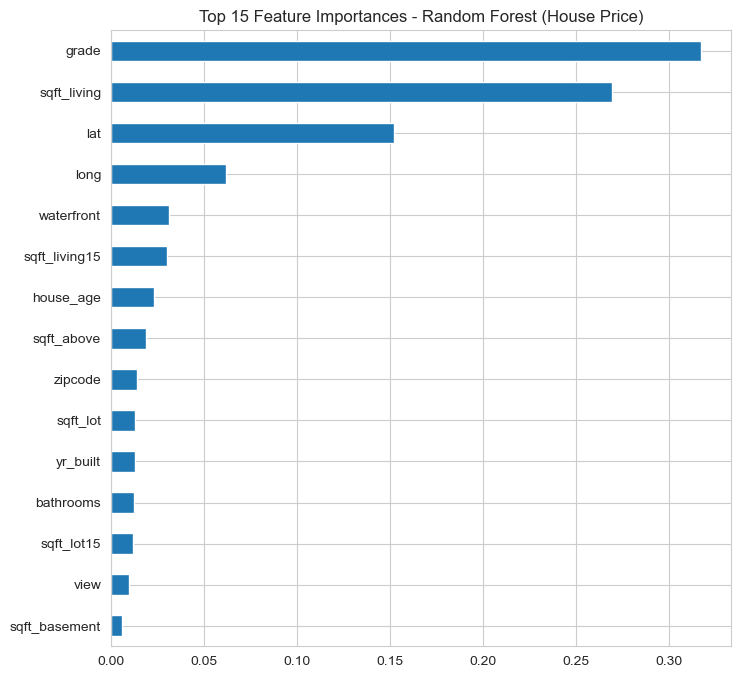

In [18]:
rf_model_h = results_h["Random Forest Regressor"]["pipeline"].named_steps["regressor"]
importances_h = pd.Series(rf_model_h.feature_importances_, index=numeric_features_h).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances_h.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest (House Price)")
plt.show()

---
# Part 2: Expanded Student Data Dataset

## 2.1 Load and inspect the data

In [19]:
students = pd.read_csv("Expanded_data_with_more_features.csv")
students = students.drop(columns=[c for c in students.columns if c.startswith("Unnamed")])
students.shape

(30641, 14)

In [20]:
students.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [21]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


In [22]:
students.isna().sum()

Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

Several categorical columns contain missing values (all except `NrSiblings`). These will be handled inside the preprocessing pipeline via imputation instead of dropping rows, to preserve as much data as possible.

## 2.2 Exploring relationships between variables

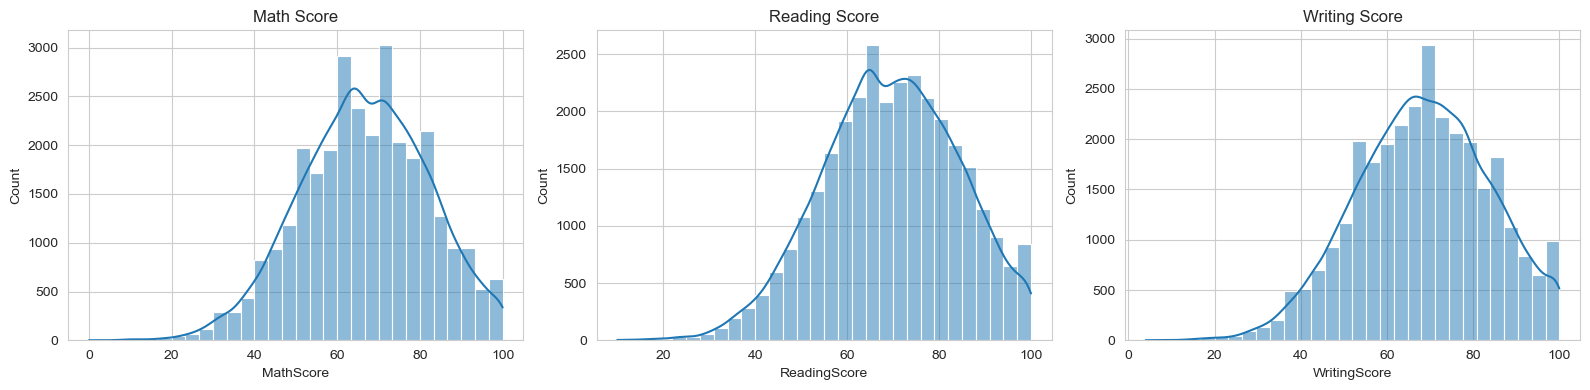

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(students["MathScore"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Math Score")
sns.histplot(students["ReadingScore"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Reading Score")
sns.histplot(students["WritingScore"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Writing Score")
plt.tight_layout()
plt.show()

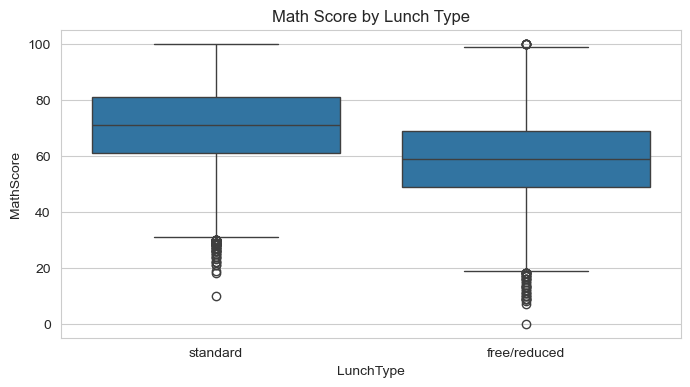

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=students, x="LunchType", y="MathScore")
plt.title("Math Score by Lunch Type")
plt.show()

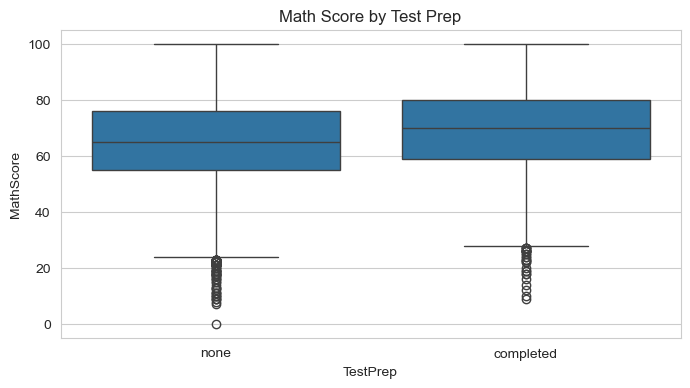

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=students, x="TestPrep", y="MathScore")
plt.title("Math Score by Test Prep")
plt.show()

## 2.3 Preparing the data for training

A regression model will be trained to predict `MathScore` from the student's demographic and academic features (gender, ethnic group, parent education, lunch type, test prep, parent marital status, sport practice, siblings count, transport means, and weekly study hours) - without using `ReadingScore` or `WritingScore` as features, to avoid leakage from scores that are strongly correlated with the target.

In [26]:
target_col = "MathScore"
feature_cols = [c for c in students.columns if c not in ["MathScore", "ReadingScore", "WritingScore"]]

X_stu = students[feature_cols]
y_stu = students[target_col]

categorical_features_s = X_stu.select_dtypes(include="object").columns.tolist()
numeric_features_s = X_stu.select_dtypes(exclude="object").columns.tolist()

categorical_features_s, numeric_features_s

(['Gender',
  'EthnicGroup',
  'ParentEduc',
  'LunchType',
  'TestPrep',
  'ParentMaritalStatus',
  'PracticeSport',
  'IsFirstChild',
  'TransportMeans',
  'WklyStudyHours'],
 ['NrSiblings'])

In [27]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stu, y_stu, test_size=0.2, random_state=42
)

X_train_s.shape, X_test_s.shape

((24512, 11), (6129, 11))

In [28]:
numeric_pipeline_s = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline_s = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_s = ColumnTransformer(transformers=[
    ("num", numeric_pipeline_s, numeric_features_s),
    ("cat", categorical_pipeline_s, categorical_features_s)
])

## 2.4 Training the models

In [29]:
models_s = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

results_s = {}

for name, model in models_s.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_s),
        ("regressor", model)
    ])
    pipe.fit(X_train_s, y_train_s)
    preds = pipe.predict(X_test_s)

    r2 = r2_score(y_test_s, preds)
    rmse = np.sqrt(mean_squared_error(y_test_s, preds))
    mae = mean_absolute_error(y_test_s, preds)

    results_s[name] = {"R2": r2, "RMSE": rmse, "MAE": mae, "pipeline": pipe, "preds": preds}

    print(f"{name}: R2={r2:.4f}  RMSE={rmse:.3f}  MAE={mae:.3f}")

Linear Regression: R2=0.2895  RMSE=12.840  MAE=10.383
Ridge Regression: R2=0.2895  RMSE=12.840  MAE=10.383
Random Forest Regressor: R2=0.1134  RMSE=14.343  MAE=11.551


## 2.5 Comparing the models

In [30]:
results_df_s = pd.DataFrame({
    name: {"R2": v["R2"], "RMSE": v["RMSE"], "MAE": v["MAE"]}
    for name, v in results_s.items()
}).T

results_df_s

,R2,RMSE,MAE
Linear Regression,0.289490,12.839762,10.382946
Ridge Regression,0.289494,12.839731,10.382927
Random Forest Regressor,0.113439,14.342545,11.550867


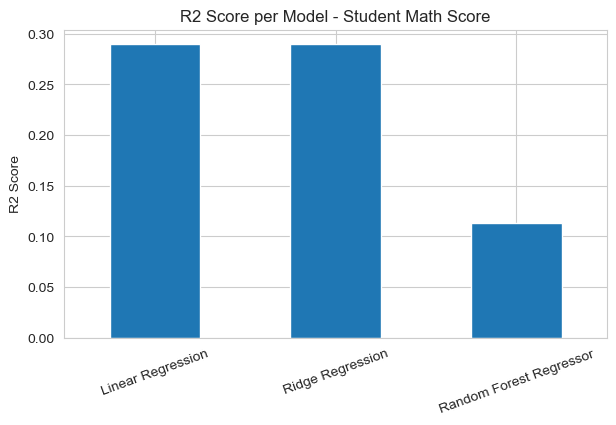

In [31]:
results_df_s["R2"].plot(kind="bar", figsize=(7, 4), title="R2 Score per Model - Student Math Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

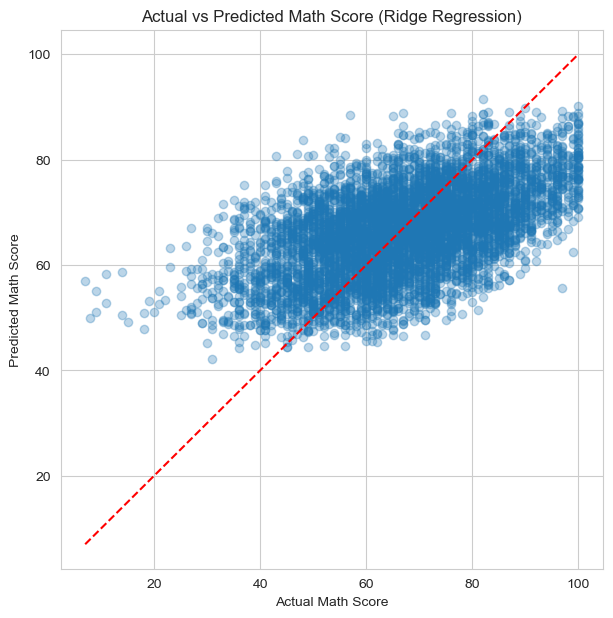

In [32]:
best_name_s = results_df_s["R2"].idxmax()
best_preds_s = results_s[best_name_s]["preds"]

plt.figure(figsize=(7, 7))
plt.scatter(y_test_s, best_preds_s, alpha=0.3)
plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], "r--")
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title(f"Actual vs Predicted Math Score ({best_name_s})")
plt.show()

## 2.6 Most influential features (Linear Regression coefficients)

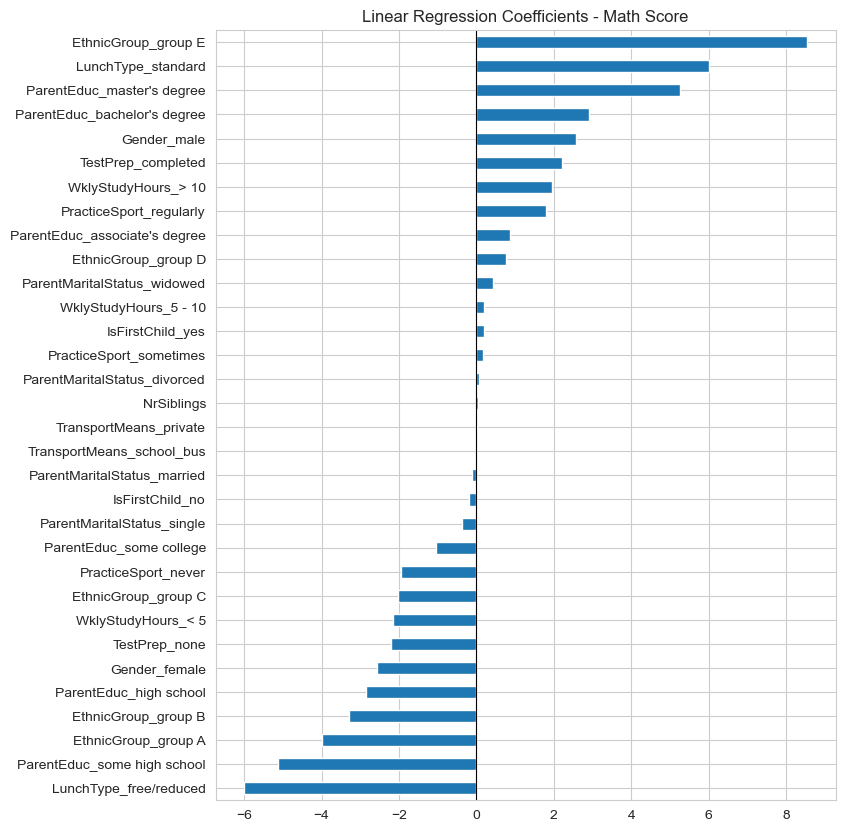

In [33]:
ohe_s = results_s["Linear Regression"]["pipeline"].named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names_s = ohe_s.get_feature_names_out(categorical_features_s)
all_feature_names_s = numeric_features_s + list(cat_names_s)

lin_model_s = results_s["Linear Regression"]["pipeline"].named_steps["regressor"]
coefs_s = pd.Series(lin_model_s.coef_, index=all_feature_names_s).sort_values()

plt.figure(figsize=(8, 10))
coefs_s.plot(kind="barh")
plt.title("Linear Regression Coefficients - Math Score")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

## 2.7 Conclusion

- **House Data**: the Random Forest Regressor achieves the highest R2 and lowest error in predicting house price, which makes sense since the relationship between price and the property features (living area, grade, location) is not fully linear.
- **Student Data**: the ability to predict Math Score from demographic and academic features alone (excluding Reading/Writing scores) is comparatively limited, which is expected since student performance depends on many factors not present in the data (personal effort, baseline ability, etc.). Adding `ReadingScore` and `WritingScore` as features would raise the R2 substantially since they are strongly correlated with each other.